# Linear Regression 2

**Agenda**

<ul>
  <li>Multiple Regression</li>
  <li>Exploring Data</li>
  <li>Handling Categorical Variables</li>
  <li>Data Prepration</li>
  <li>Implementation</li>
<ul>
  <li>Defining Hypothesis</li>
  <li>Defining Error Function</li>
  <li>Defining Gradient</li>
  <li>Defining Gradient Descent</li>
</ul>
  <li>Linear Regression Model using Scikit-learn</li>
  <li>Adjsuted R<sup>2</sup></li>
  <li>Statsmodel Implementation</li>
  <li>Assumptions in Data</li>
  <li>VIF - Variance Inflation Factor</li>
  <li>Removing all those variables which have Multicolinearity</li>
  <li>Splitting Data for Evaluation</li>
  <li>Predictions using test data set</li>
  <li>Evaluating Model Performance</li>
  <li>Residual Analysis</li>
  <li>Log Transformation</li>
</ul>

## Multiple Regression

* Multiple regression is an extension of simple linear regression where the model involves more than one independent variable to predict the dependent variable. This allows for more complex relationships between the dependent variable and multiple factors.

* In essence, multiple regression is the extension of ordinary least-squares (OLS) regression because it involves more than one explanatory variable.
   * Ordinary Least Squares regression (OLS) is a common technique for estimating coefficients of linear regression equations which describe the relationship between one or more independent quantitative variables and a dependent variable (simple or multiple linear regression).

   ![picture](https://drive.google.com/uc?export=view&id=1i0lXAUZwOF55OWLDHNXJwFgqzyDV1__t)

   ![picture](https://drive.google.com/uc?export=view&id=14AOUC8SXRCj3KswkPIyF6H9pzV5EVXEg)

* Interpreting Coefficients
   * Significance: The coefficient's p-value indicates its statistical significance. A low p-value suggests that the variable is a significant predictor of Y.
   * Magnitude: The absolute value of the coefficient reflects the strength of the relationship between the variable and Y. A larger absolute value indicates a stronger relationship.
   * Direction: The sign of the coefficient (positive or negative) indicates the direction of the relationship. A positive coefficient means that as the independent variable increases, so does the dependent variable. A negative coefficient means that as the independent variable increases, the dependent variable decreases.

* Assumptions of Multiple Regression
   * Linearity: The relationship between Y and each Xi is linear.
   * Independence: The observations are independent of each other.
   * Homoscedasticity: The variance of the errors is constant across all levels of the independent variables.
   * Normality: The errors are normally distributed.
   * No multicollinearity: The independent variables are not perfectly correlated with each other.

### Cost Function



The cost function measures how well your model fits the training data. In the case of multiple regression, it quantifies the error between the predicted values (h<sub>β</sub>(x)) and the actual values (y) in your dataset.


The Mean Squared Error (MSE) is a commonly used cost function:

![picture](https://drive.google.com/uc?export=view&id=1xVoAQa-ri80m33jLaSycPVsSRVauK92h)

Where:
<ul>
  <li>m is the number of training examples.</li>
  <li>x<sup>(i)</sup>  is the feature vector of the ith training example.</li>
  <li>y<sup>(i)</sup>  is the actual output for the ith example.</li>
  <li>h<sub>β(</sub>x<sup>(i)</sup>) is the predicted output for the ith example using the current parameters β.</li>
</ul>



### Gradient

The gradient of the cost function indicates the direction and magnitude of the steepest ascent (or descent) of the function. In the context of multiple regression, it tells us how to update the coefficients (β) to minimize the cost function.

The gradient of the cost function with respect to each coefficient β<sub>j</sub>  is calculated as:

![picture](https://drive.google.com/uc?export=view&id=1TjD1krL7P2i6x7hRVRN4XU1Zq_03dce6)

Where:

<ul>
  <li>x<sub>j</sub><sup>i</sup> is the jth feature of the ith training example</li>
  <li>h<sub>β(</sub>x<sup>(i)</sup>) is the predicted output for the ith example using the current parameters β.</li>
  <li>y<sup>(i)</sup>  is the actual output for the ith example.</li>
</ul>

This expression computes the partial derivative of the cost function with respect to a specific coefficient β<sub>j</sub>, considering the contribution of each training example.

**Optimization:**

With the cost function and gradient, you can employ optimization algorithms like gradient descent to iteratively update the coefficients (β) until convergence. In each iteration, the coefficients are adjusted in the direction that minimizes the cost function, ultimately leading to a set of coefficients that best fit the training data.







## Exploring Data

[Download Dataset From Here](https://drive.google.com/drive/folders/1qtfW3ie-GaLPovL-8oesW_m-VHzzYIG1)

In [ ]:
# Importing all required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# reading a CSV file named "data.csv" located in the "Data" folder on the your Google Drive and stores it as a DataFrame df
# write your data file path
df = pd.read_csv('/content/CarPred.csv')

## Data Prepration

* In data preparation, first we will drop all categorical variables. These variables are typically not suitable for direct numerical representation and may require encoding techniques like one-hot encoding or label encoding to convert them into a format that the model can process effectively.

* Data is split into input features (X) and target variable (Y), with standardization or normalization applied to the input features to ensure uniform scaling and mitigate the influence of differences in the magnitude of features, enabling more stable and efficient model training.

In [ ]:
df.make.value_counts()

,count
make,
hyundai,3375
toyota,3375
suzuki,3359
maruti,3343
honda,3314
ford,3234


In [ ]:
# drops the "make" and "model" columns from the DataFrame "df" along the column axis (axis=1) in place, meaning the changes are applied directly to the DataFrame without creating a copy.
df.drop(["make", "model"], axis = 1, inplace=True)

In [ ]:
df.head()

,transmission_type,seats_cop,seats_family,seats_large,fuel_cng,fuel_diesel,fuel_electric,fuel_lpg,fuel_patrol,seller_dealer,seller_self,year,km_driven,engine,max_power,selling_price
0,0,0,0,1,0,0,1,0,0,0,1,2009,42945,2492,287,210447.937555
1,0,0,0,1,0,0,0,0,1,1,0,2003,176401,3240,88,272870.715932
2,1,0,0,0,0,0,0,0,1,1,1,2018,46852,3250,169,251387.190744
3,1,0,0,0,0,1,0,0,0,1,1,2014,162580,1317,99,139196.325731
4,1,0,0,1,0,1,0,0,0,1,1,2004,11264,3268,196,227022.794299


In [ ]:
# separating the DataFrame "df" into input features X and target variable Y.
# X contains all columns except "selling_price", while Y contains only the "selling_price" column.

X = df[df.columns.drop("selling_price")]
Y = df["selling_price"]

In [ ]:
# converting the input features X and the target variable Y from pandas DataFrame objects to NumPy arrays.
# This conversion is often done to prepare the data for machine learning algorithms that require input in the form of NumPy arrays rather than pandas DataFrames.
X = X.to_numpy()
Y = Y.to_numpy()

In [ ]:
# standard normalisation
# calculating the mean (u) and standard deviation (std) along each column (axis=0) of the input features X.
# These statistics are used for standard normalization, where each feature is transformed to have a mean of 0 and a standard deviation of 1.
# This step ensures that all features are on the same scale, which can help improve the performance of machine learning algorithms, particularly those sensitive to feature scales like distance-based algorithms.

u = np.mean(X, axis=0)
std = np.std(X, axis=0)

In [ ]:
u

array([4.99250000e-01, 1.25150000e-01, 2.50350000e-01, 5.00400000e-01,
       3.08500000e-02, 6.35500000e-02, 1.23900000e-01, 2.51050000e-01,
       4.99600000e-01, 4.98350000e-01, 4.94100000e-01, 2.01051390e+03,
       1.00041147e+05, 2.99900990e+03, 2.74710600e+02])

In [ ]:
std

array([4.99999437e-01, 3.30888920e-01, 4.33214586e-01, 4.99999840e-01,
       1.72911184e-01, 2.43949580e-01, 3.29467434e-01, 4.33617225e-01,
       4.99999840e-01, 4.99997277e-01, 4.99965189e-01, 6.35487268e+00,
       5.77092436e+04, 1.15653080e+03, 1.29838297e+02])

In [ ]:
# performing standard normalization on the input features X by subtracting the mean (u) from each feature and then dividing by the standard deviation (std).
# Standard normalization ensures that all features have a mean of 0 and a standard deviation of 1, which helps in centering the data and bringing it to a common scale.
# This preprocessing step is essential for many machine learning algorithms, especially those based on gradient descent, as it can speed up convergence and improve the overall performance of the model.

X = (X - u)/std

In [ ]:
# adding a column of ones to the input features matrix X.
# The added column of ones represents the intercept term in linear regression models.
# Including this intercept term allows the model to learn an offset from the origin and is necessary for capturing relationships,
# where the dependent variable is not zero when all independent variables are zero.

ones = np.ones((X.shape[0],1))
X = np.hstack((ones, X))

In [ ]:
print(X.shape, Y.shape)

(20000, 16) (20000,)


##  Implementation

### Defining Hypothesis

In [ ]:
# implementing the hypothesis equation for linear regression, where the predicted value Y_ is calculated by taking the dot product of the feature vector x and the parameter vector θ.
# It iterates over each feature value in x, multiplies it by the corresponding parameter value in θ, and sums the results to obtain the predicted output.

def hypothesis(x, theta):
    y_ = 0.0
    n = x.shape[0]
    for i in range(n):
      y_ += (theta[i]*x[i])
    return y_

### Defining Error Function

In [ ]:
# calculating the mean squared error (MSE) between the actual target values y and the predicted values obtained from the hypothesis function, given the input features x and the parameter vector θ.
# It iterates over each data point, computes the squared difference between the actual and predicted values, and sums these squared errors.
# Finally, it returns the average squared error by dividing the total squared error by the number of data points.

def error(x, y, theta):
  e = 0.0
  m = X.shape[0]

  for i in range(m):
    y_ = hypothesis(X[i], theta)
    e += (y[i] - y_)**2

  return e/m

### Defining Gradient

In [ ]:
# computes the gradient of the cost function with respect to each parameter θj in the parameter vector θ.
# It iterates over each parameter θj  and for each parameter, it iterates over each data point to compute the gradient contribution from that data point.
# The gradient is the sum of the product of the error (the difference between the predicted and actual values) and the corresponding feature value for all data points, divided by the number of data points.
# Finally, it returns the average gradient for each parameter.

def gradient(X, y, theta):
  m, n = X.shape

  grad = np.zeros((n,))

  # for all values of j
  for j in range(n):
    # sum over all examples
    for i in range(m):
      y_ = hypothesis(X[i], theta)
      grad[j] += (y_ - y[i])*X[i][j]

  # out of loops
  return grad/m

### Defining Gradient Descent

In [ ]:
# implementing gradient descent to minimize the cost function iteratively.
# It initializes the parameter vector θ with zeros and iterates over a fixed number of epochs (max_epochs), computing the error and gradient at each step using the error and gradient functions.
# Then, it updates each parameter θj​ by subtracting the product of the learning rate and the corresponding gradient component.
# The process continues until convergence or until the maximum number of epochs is reached.
# Finally, it returns the optimized parameter vector θ and a list of errors at each iteration for analysis.

def gradient_descent(X, y, learning_rate=0.1, max_epochs = 100):
  m, n = X.shape
  theta = np.zeros((n,))
  error_list = []

  for i in range(max_epochs):
    e = error(X, y, theta)
    error_list.append(e)

    # gradient descent
    grad = gradient(X, y, theta)
    for j in range(n):
      theta[j] = theta[j] - learning_rate*grad[j]


  return theta, error_list

In [ ]:
# snippet measures the time taken to execute the gradient descent algorithm. It starts a timer using time.time(), then calls the gradient_descent function to optimize the parameters θ using the input features X and target variable Y.
# Afterward, it stops the timer, calculates the duration of execution, and prints the time taken for the gradient descent process to complete.
# This is useful for assessing the algorithm's efficiency and comparing different implementations or parameter settings.

import time
start = time.time()
theta, error_list = gradient_descent(X, Y)
end = time.time()
print("Time taken is: ", end-start)

Time taken is:  274.7797317504883


In [ ]:
print(theta)

[ 2.66264733e+05 -6.83299890e+02  1.46785635e+02  1.38290563e+02
  5.99317666e+01  5.00566845e+02  4.10095966e+01  6.94401366e+01
 -1.69202454e+02  5.47068986e+01  5.09551339e+02 -1.03189963e+03
  6.98370728e+00  2.51785560e+02 -7.37756347e+01  6.35011335e+04]


## Linear Regression Model using Scikit-learn

In [ ]:
# The linear_model module in Scikit-Learn provides an implementation of linear regression.
#  importing the LinearRegression class from the linear_model module in Scikit-Learn and initializes a linear regression model object named model
# Then, we prepare the input features (X) by dropping the "selling_price" column from the DataFrame and assigns the target variable (Y) to be the "selling_price" column.
# This sets up the data for training the linear regression model.

from sklearn.linear_model import LinearRegression
model = LinearRegression()

X = df[df.columns.drop('selling_price')]
Y = df["selling_price"]

In [ ]:
# stadardization
# importing the StandardScaler and MinMaxScaler classes from the preprocessing module in Scikit-Learn. .
# Then, it initializes a StandardScaler object named sc.
# This scaler will be used to standardize the input features, ensuring that they have a mean of 0 and a standard deviation of 1.
#  Standardization helps in scaling the features to a similar range, which can improve the performance of certain machine learning algorithms, such as gradient descent-based methods like linear regression.

from sklearn.preprocessing import StandardScaler, MinMaxScaler
sc = StandardScaler()

In [ ]:
# standardizes the input features stored in the DataFrame X.
# It first extracts the column names from X and then applies the fit_transform method of the StandardScaler object sc to standardize the corresponding columns in X.
# standardization ensures that all features have a mean of 0 and a standard deviation of 1, which can help improve the performance of machine learning models, especially those sensitive to the scale of the features.

cols = X.columns
X[cols] = sc.fit_transform(X[cols])
# x = sc.fit_transform(x) this will result into a numpy array

<ipython-input-27-f5ba76c9be82>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[cols] = sc.fit_transform(X[cols])


In [ ]:
X.head()

,transmission_type,seats_cop,seats_family,seats_large,fuel_cng,fuel_diesel,fuel_electric,fuel_lpg,fuel_patrol,seller_dealer,seller_self,year,km_driven,engine,max_power
0,-0.998501,-0.378224,-0.577889,0.9992,-0.178415,-0.260505,2.659140,-0.578967,-0.9992,-0.996705,1.011870,-0.238227,-0.989376,-0.438389,0.094652
1,-0.998501,-0.378224,-0.577889,0.9992,-0.178415,-0.260505,-0.376061,-0.578967,1.0008,1.003305,-0.988269,-1.182384,1.323182,0.208373,-1.438024
2,1.001501,-0.378224,-0.577889,-1.0008,-0.178415,-0.260505,-0.376061,-0.578967,1.0008,1.003305,1.011870,1.178009,-0.921675,0.217020,-0.814171
3,1.001501,-0.378224,-0.577889,-1.0008,-0.178415,3.838703,-0.376061,-0.578967,-0.9992,1.003305,1.011870,0.548571,1.083689,-1.454358,-1.353303
4,1.001501,-0.378224,-0.577889,0.9992,-0.178415,3.838703,-0.376061,-0.578967,-0.9992,1.003305,1.011870,-1.025024,-1.538352,0.232584,-0.606220


In [ ]:
# The linear_model module in Scikit-Learn provides an implementation of linear regression.
from sklearn.linear_model import LinearRegression
# Creating an instance of the linear regression model.
model = LinearRegression()

In [ ]:
# fitting the linear regression model model to the standardized input features X and the target variable Y
# The fit method trains the model by adjusting its parameters to minimize the difference between the predicted values and the actual target values.
model.fit(X, Y)

LinearRegression()

In [ ]:
# initializing an instance of the LinearRegression model from scikit-learn, which will be used for linear regression analysis.
LinearRegression()

LinearRegression()

In [ ]:
# Retrieving the intercept from the linear regression model.
model.intercept_

266271.8057707528

In [ ]:
# The coefficients of the linear regression model, indicating the weight/importance of each feature in predicting the target variable.
model.coef_

array([-6.83234746e+02,  1.52442100e+02,  1.45427665e+02,  6.77434690e+01,
        5.01795178e+02,  4.26800365e+01,  7.19523318e+01, -1.66045123e+02,
        5.82983773e+01,  5.09457373e+02, -1.03191098e+03,  6.79470723e+00,
        2.51905362e+02, -7.38843334e+01,  6.35028215e+04])

In [ ]:
# Calculating the coefficient of determination R square of the linear regression model using the input features X and target variable Y.
model.score(X, Y)

0.5729801349938517

## Adjusted R_Square

Adjusted R_Square is a modified version of the coefficient of determination (R<sup>2</sup>) that adjusts for the number of predictors in a regression model.

While (R<sup>2</sup>) measures the proportion of variance in the dependent variable explained by the independent variables, adjusted (R<sup>2</sup>) penalizes for the inclusion of unnecessary predictors that do not significantly improve the model's explanatory power.

The formula for adjusted (R<sup>2</sup>):

![picture](https://drive.google.com/uc?export=view&id=19kd02xSdA444W3CYFZNr-ZFoLkiEd4US)


Adjusted (R<sup>2</sup>) increases only if the new term improves the model more than would be expected by chance. It avoids overestimating the performance of the model when additional predictors are added, as (R<sup>2</sup>) typically increases with the addition of predictors regardless of their actual usefulness.

In [ ]:
print("Adjusted R-squared: ", 1 - (1-model.score(X,Y))*(len(Y) - 1)/(len(Y) - 1 - X.shape[1] - 1))

Adjusted R-squared:  0.5726382284813112


## Statsmodel Implementation

In [ ]:
# importing the statsmodels module, providing access to its API for statistical modeling and analysis
import statsmodels.api as sm

In [ ]:
# adds a constant term to the feature matrix X, then performs ordinary least squares (OLS) regression using statsmodels, fitting the model to the target variable Y.

X_sm = sm.add_constant(X)
# OLS -> ordinary least square
sm_model = sm.OLS(Y, X_sm).fit()

In [ ]:
# summary of the regression model sm_model
# providing detailed information about the model's performance, coefficients, statistical significance, and goodness of fit measures like R-squared and adjusted R-squared.
# It gives insights into how well the model fits the data and the significance of each predictor variable.

print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:          selling_price   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     1788.
Date:                Tue, 17 Sep 2024   Prob (F-statistic):               0.00
Time:                        07:04:19   Log-Likelihood:            -2.4662e+05
No. Observations:               20000   AIC:                         4.933e+05
Df Residuals:                   19984   BIC:                         4.934e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              2.663e+05    387.92

## Assumptions in Data

<ul>
  <li>Input and Target Variable Linear Relationship:</li>
<ul>
  <li>This assumption assumes that there is a linear relationship between the input variables (also known as independent variables or features) and the target variable.</li>
  <li>Linear regression models, such as ordinary least squares (OLS), assume that the relationship between the predictors and the response variable is linear. This means that a change in the predictor variable leads to a proportional change in the response variable.</li>
  <li>Scatter plots or correlation coefficients can be used to visualize or quantify the linear relationship between the input variables and the target variable. If the relationship appears nonlinear, transformations or more complex modeling techniques may be necessary.</li>
</ul>

  <li>No Multicollinearity:</li>
<ul>
  <li>Multicollinearity occurs when two or more predictor variables in a regression model are highly correlated with each other. This can cause problems in the estimation of the regression coefficients.</li>
  <li>Multicollinearity can inflate the standard errors of the regression coefficients, making them unreliable for inference. It can also make it difficult to interpret the individual effects of predictor variables on the target variable.</li>
  <li>Variance inflation factor (VIF) and correlation matrices are common tools used to detect multicollinearity. A VIF greater than 10 or high pairwise correlations (typically above 0.7 or 0.8) between predictor variables may indicate multicollinearity.</li>
  <li>To address multicollinearity, one approach is to remove one of the correlated variables from the model. Alternatively, techniques such as ridge regression or principal component analysis (PCA) can be used to mitigate its effects while retaining all variables in the model.</li>
</ul>

  <li>Target Variable Follows Normal Distribution:</li>
<ul>
  <li>This assumption implies that the values of the target variable (also known as the dependent variable or response variable) are normally distributed within the population.</li>
  <li>Normality is important because many statistical tests and estimators assume that the data are normally distributed. It facilitates the interpretation of statistical tests and helps ensure the validity of statistical inference.</li>
</ul>
</ul>

### VIF - Variance Inflation Factor

<ul>
  <li>The Variance Inflation Factor (VIF) is a statistical tool used in regression analysis to detect and measure the severity of multicollinearity. </li>
  </li>Multicollinearity occurs when two or more independent variables in a regression model are highly correlated with each other. </li>
  <li>This can lead to several problems, including:</li>
<ul>
  <li>Inflated variances of the regression coefficients: This makes it difficult to accurately estimate the true effect of each independent variable on the dependent variable.</li>
  <li>Unreliable coefficient estimates: Even if the coefficients are statistically significant, they may not be reliable enough to draw meaningful conclusions.</li>
  <li>Instability of the model: Small changes in the data can lead to large changes in the estimated coefficients.</li>
</ul>
</ul>

The VIF calculates how much the variance of a regression coefficient is inflated due to multicollinearity. It is calculated for each independent variable in the model. A VIF value of 1 indicates no multicollinearity, while values greater than 1 indicate some degree of multicollinearity. The higher the VIF value, the more severe the multicollinearity.

Here are some general guidelines for interpreting VIF values:

<ul>
  <li>VIF < 5: No multicollinearity issue.</li>
  <li>5 ≤ VIF < 10: Moderate multicollinearity, may not be a major problem.</li>
  <li>VIF ≥ 10: Severe multicollinearity, investigate further and consider remedial actions.</li>
</ul>

It is important to note that these are just guidelines, and the decision of whether or not to take action to address multicollinearity will depend on the specific context of your analysis.

Here are some of the ways to address multicollinearity:

<ul>
  <li>Remove one or more of the collinear variables: This is the most common approach, but it should only be done if the variable(s) being removed are not theoretically important to the model.</li>
  <li>Combine collinear variables: If two or more variables are measuring the same underlying construct, they can be combined into a single variable.</li>
  <li>Use ridge regression or LASSO: These are regression techniques that can help to reduce the impact of multicollinearity on the coefficient estimates.</li>
</ul>

VIF - Variance Inflation Factor


In [ ]:
# importing the function variance_inflation_factor from the statsmodels.stats.outliers_influence module, which is commonly used to compute the variance inflation factor (VIF) for predictor variables in a regression model.
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# Compute variance inflation factor (VIF) for predictor variables
# and create a DataFrame to store the results
vif = pd.DataFrame()

# Set the features column in the DataFrame to the column names of X
vif['features'] = X.columns

# Compute the VIF for each predictor variable in X
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Round the VIF values to two decimal places
vif['VIF'] = round(vif['VIF'], 2)

# Sort the DataFrame by VIF values in descending order
vif = vif.sort_values(by='VIF', ascending=False)

# Display the DataFrame with feature names and their corresponding VIF values
vif

,features,VIF
8,fuel_patrol,8.56
7,fuel_lpg,6.81
6,fuel_electric,4.37
5,fuel_diesel,2.86
3,seats_large,2.52
2,seats_family,2.26
4,fuel_cng,1.93
1,seats_cop,1.76
0,transmission_type,1.00
9,seller_dealer,1.00


Above code computes the variance inflation factor (VIF) for each predictor variable in X to check for multicollinearity.

It creates a DataFrame vif to store the results, where each row corresponds to a predictor variable and its associated VIF value.

The VIF quantifies how much the variance of an estimated regression coefficient is increased because of collinearity.

### Removing all those variables which  have Multicollinearity

In our dataset, although multicollinearity is not significant, we'll simulate it to demonstrate how to address it effectively.

In [ ]:
# Define the columns to keep, excluding those suspected of multicollinearity
cols2 = ["max_power", "transmission_type", "year", "km_driven", "fuel_electric", "seats_cop"]

In [ ]:
# Extract the selected columns from the feature matrix
X2 = X[cols2]

# Add a constant term for the intercept in the feature matrix
X2_sm = sm.add_constant(X2)

# Fit an Ordinary Least Squares (OLS) regression model using the selected features
sm_model = sm.OLS(Y, X2_sm).fit()

In [ ]:
# Print the summary statistics of the regression model
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:          selling_price   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     4467.
Date:                Tue, 17 Sep 2024   Prob (F-statistic):               0.00
Time:                        07:12:52   Log-Likelihood:            -2.4663e+05
No. Observations:               20000   AIC:                         4.933e+05
Df Residuals:                   19993   BIC:                         4.933e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              2.663e+05    387.93

In [ ]:
X2 = X[cols2]

X2_sm = sm.add_constant(X2)

sm_model = sm.OLS(Y, X2_sm).fit()

In [ ]:
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:          selling_price   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     4467.
Date:                Tue, 17 Sep 2024   Prob (F-statistic):               0.00
Time:                        07:13:15   Log-Likelihood:            -2.4663e+05
No. Observations:               20000   AIC:                         4.933e+05
Df Residuals:                   19993   BIC:                         4.933e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              2.663e+05    387.93

In [ ]:
# Calculate the Variance Inflation Factor (VIF) for each feature to check for multicollinearity
vif = pd.DataFrame()
x_t = X2
vif['features'] = x_t.columns
vif['VIF'] = [variance_inflation_factor(x_t.values, i) for i in range(x_t.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by='VIF', ascending=False)
vif

,features,VIF
0,max_power,1.0
1,transmission_type,1.0
2,year,1.0
3,km_driven,1.0
4,fuel_electric,1.0
5,seats_cop,1.0


### Splitting Data for Evaluation

 The process of splitting data into training and testing sets, combined with maintaining consistency using a random seed, is fundamental for developing robust and reliable machine learning models.

 It ensures that models generalize well to unseen data and enables consistent evaluation of model performance.







In [ ]:
# Importing the train_test_split function from the sklearn.model_selection module
from sklearn.model_selection import train_test_split

In [ ]:
# Splitting the data into training and testing sets with 90% for training and 10% for testing,
# while maintaining consistency using a random seed of 1
x_train, x_test, y_train, y_test = train_test_split(X2, Y, test_size = 0.1, random_state=1)

In [ ]:
print("Training set shape X: ", x_train.shape)
print("Training set shape Y: ", y_train.shape)
print("Test set shape X: ", x_test.shape)
print("Test set shape Y: ", y_test.shape)

Training set shape X:  (18000, 6)
Training set shape Y:  (18000,)
Test set shape X:  (2000, 6)
Test set shape Y:  (2000,)


In [ ]:
# Creating a Linear Regression model instance and fitting it to the training data
final_model = LinearRegression()
final_model.fit(x_train, y_train)

LinearRegression()

In [ ]:
# Computing the R-squared score of the final model on the training data
final_model.score(x_train, y_train)

0.5721401925646443

In [ ]:
# Getting the intercept of the final model
final_model.intercept_

266207.0902900053

In [ ]:
# Getting the coefficients of the final model
final_model.coef_

array([ 6.35529402e+04, -6.31518829e+02,  2.44810594e+02,  1.24676617e+02,
       -1.36838783e+02, -4.51104629e+01])

### Predictions using test data set

In [ ]:
# Generating predictions on the test dataset using the final trained model
y_pred = final_model.predict(x_test)
# y_pred contains the predicted values of the target variable based on the features in the test dataset

### Evaluating Model Performance


In [ ]:
# model performance
# Importing evaluation metrics for regression models from scikit-learn
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
# These metrics will be used to assess the performance of the regression model

In [ ]:
print("Mean absolute error: ", mean_absolute_error(y_pred, y_test))
print("Mean squared error: ", mean_squared_error(y_pred, y_test))
print("Root Mean squared error: ", np.sqrt(mean_squared_error(y_pred, y_test)))
print("Mean absolute percentage error: ", mean_absolute_percentage_error(y_pred, y_test))

Mean absolute error:  42831.8168004857
Mean squared error:  2889049562.0473557
Root Mean squared error:  53749.879646817404
Mean absolute percentage error:  0.1701119256512152


<ipython-input-58-f34bd58de931>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train)


<Axes: xlabel='selling_price', ylabel='Density'>

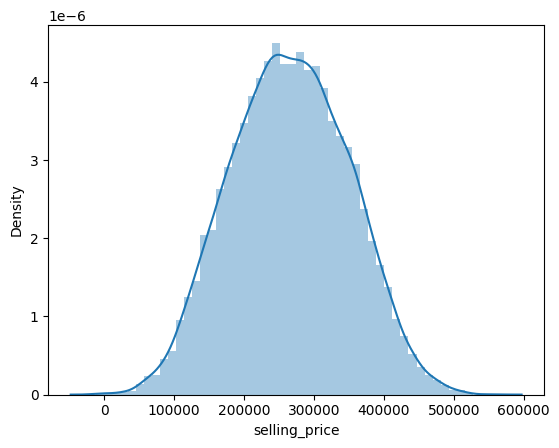

In [ ]:
# Plotting the distribution of the target variable (y_train) using seaborn
sns.distplot(y_train)

* The resulting plot is a normal distribution curve, it indicates that the distribution of the target variable in the training data approximates a normal distribution.

* Combining this observation with the assumption that the target variable follows a normal distribution, we reinforce the notion that our data aligns with this assumption.

* By verifying that the target variable conforms to a normal distribution, we validate an essential assumption underlying various statistical techniques and machine learning algorithms. This validation enhances the reliability and interpretability of our analyses and predictions. Furthermore, it enables us to make informed decisions about the suitability of certain modeling approaches and the applicability of statistical tests that assume normality.

## Residual Analysis

* Residual analysis is an essential step in evaluating the performance of a multiple linear regression model. It involves examining the residuals (errors) of the model to assess how well the model fits the data and whether the assumptions of linear regression hold. Residuals are the differences between the observed values and the predicted values of the dependent variable.

* What Are Residuals?
   * In a multiple linear regression model, residuals are defined as:

       * Residual = y<sub>actual</sub> - y<sub>predicted</sub>

Where:

  * y<sub>actual</sub> is the actual observed value of the dependent variable.
  * y<sub>predicted</sub> is the value predicted by the regression model.

### Normality of Errors

<ul>
  <li>In the context of linear regression, the errors or residuals should ideally follow a normal distribution. This means that the distribution of the discrepancies between the observed and predicted values should resemble a bell curve.</li>
  <li>A normal distribution of errors indicates that the model is capturing the underlying patterns in the data effectively. Deviations from normality may suggest that the model is inadequately capturing certain features of the data or that there are influential outliers skewing the distribution.</li>
</ul>

In [ ]:
# errors normally distributed
# Predicting the target variable using the final linear regression model and storing the predictions in the 'pred' variable
pred = final_model.predict(x_train)

In [ ]:
# Calculating the residuals by subtracting the actual target variable values from the predicted values

errors = pred - y_train # residuals

<ipython-input-61-4a151ca7bc24>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(errors)


<Axes: xlabel='selling_price', ylabel='Density'>

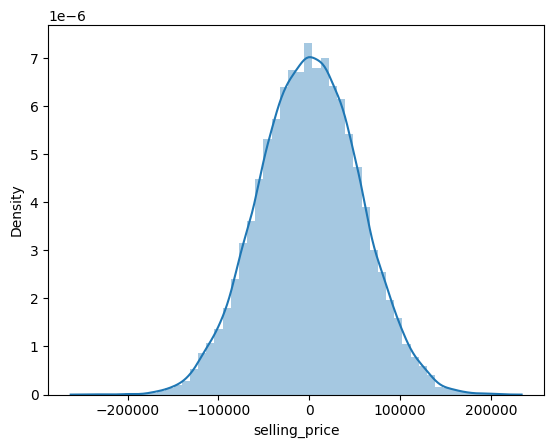

In [ ]:
sns.distplot(errors)

<ul>
  <li>A normally distributed error plot indicates that the linear regression model's assumptions regarding the distribution of errors are met. </li>
  <li>This normal distribution suggests that the model captures the underlying patterns in the data well, with errors symmetrically distributed around zero. It indicates that the model's predictions are unbiased on average and provides confidence in the model's performance.</li>
</ul>

### Autocorrelation and Heteroscedasticity

**Autocorrelation:** Autocorrelation refers to the correlation between the error terms in a regression model. In a time series context, it refers to the correlation between a variable's current value and its past values at different lags. In the context of linear regression, autocorrelation occurs when the error terms exhibit patterns or correlations with each other, indicating that there is still some information in the errors that the model has not captured. Autocorrelation violates the assumption of independence of errors, which is crucial for the reliability of regression analysis.

**Heteroscedasticity:** Heteroscedasticity, on the other hand, refers to the situation where the variance of the errors (or residuals) in a regression model is not constant across all levels of the independent variables. In simpler terms, it means that the spread of the residuals differs for different values of the predictor variables. Heteroscedasticity violates the assumption of homoscedasticity, which states that the variance of the errors should remain constant across all levels of the independent variables. When heteroscedasticity is present, it can lead to inefficient estimates of the regression coefficients and affect the reliability of statistical inferences drawn from the model.

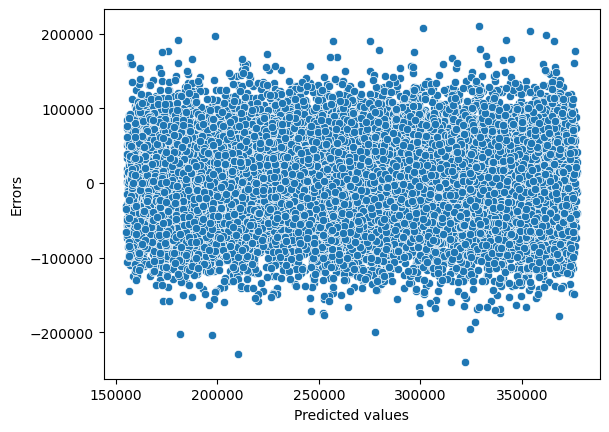

In [ ]:
# Autocorrelation and Heteroscedasticity
# plot (predicted values vs residuals)

# Generating a scatter plot to visualize predicted values versus residuals
sns.scatterplot(x=pred, y=errors)
plt.xlabel("Predicted values")
plt.ylabel("Errors")
plt.show()


The plot helps us identify any patterns or trends between the predicted values and the errors, which can indicate the presence of autocorrelation or heteroskedasticity in the model's residuals.

The scatter plot appears roughly cylindrical in shape, it suggests the presence of heteroskedasticity, where the spread of errors varies across different ranges of predicted values.

This pattern indicates that the variance of errors is not consistent, violating one of the assumptions of linear regression.

Additionally, if there are any discernible patterns or trends in the scatter plot, it could also indicate the presence of autocorrelation, suggesting that the errors are correlated with each other.

Both heteroskedasticity and autocorrelation can affect the reliability and accuracy of the linear regression model's predictions.

### Handling High-End Car Data

Filtering out high-end car data (selling price > 25 lakhs) from the dataset to mitigate skewness and potential outliers that may not align with the resale market being analyzed.


Filtering out high-end car data with selling prices greater than 25 lakhs is important according to the text provided because it helps address two main issues:

<ul>
  <li>Skewness Mitigation: If the distribution of selling prices in the dataset is highly right-skewed. By removing high-end car data, which likely represents outliers in terms of price, the skewness of the distribution is reduced. This is crucial because skewed data distributions can affect the performance of linear regression models and violate the assumption of normality.</li>
  <li>Outlier Removal: High-end cars may not align with the resale market being analyzed. Their inclusion could introduce outliers that disproportionately influence model fitting and prediction accuracy. By filtering out these high-end cars, the author aims to focus the analysis on the majority of cars within the resale market, potentially improving the model's ability to generalize and make accurate predictions for typical resale scenarios.</li>
</ul>

In [ ]:
df3 = df[df["selling_price"] <= 25]

In [ ]:
df3.head()

,transmission_type,seats_cop,seats_family,seats_large,fuel_cng,fuel_diesel,fuel_electric,fuel_lpg,fuel_patrol,seller_dealer,seller_self,year,km_driven,engine,max_power,selling_price
0,0,0,0,1,0,0,1,0,0,0,1,2009,42945,2492,287,210447.937555
1,0,0,0,1,0,0,0,0,1,1,0,2003,176401,3240,88,272870.715932
2,1,0,0,0,0,0,0,0,1,1,1,2018,46852,3250,169,251387.190744
3,1,0,0,0,0,1,0,0,0,1,1,2014,162580,1317,99,139196.325731
4,1,0,0,1,0,1,0,0,0,1,1,2004,11264,3268,196,227022.794299


In [ ]:
df3.shape

(19993, 16)

<ipython-input-66-79e869ad7a3a>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df3["selling_price"])


<Axes: xlabel='selling_price', ylabel='Density'>

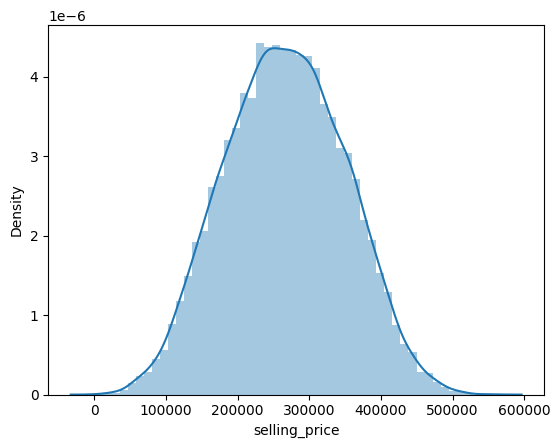

In [ ]:
sns.distplot(df3["selling_price"])

Again the plot of Target data is Normal Distribution.

## Statsmodel Implementation(Again)

In [ ]:
X = df3[cols2]
Y = df3["selling_price"]

In [ ]:
X.shape

(19993, 6)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.1, random_state=1)

In [ ]:
sc = StandardScaler()
cols = x_train.columns
x_train[cols] = sc.fit_transform(x_train[cols])

<ipython-input-69-53e462b909d4>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[cols] = sc.fit_transform(X[cols])


In [ ]:
x_train.head()

,max_power,transmission_type,year,km_driven,fuel_electric,seats_cop
0,0.094124,-0.998251,-0.238299,-0.989571,2.659221,-0.378299
1,-1.438958,-0.998251,-1.182444,1.323320,-0.376050,-0.378299
2,-0.814939,1.001752,1.177919,-0.921860,-0.376050,-0.378299
3,-1.354214,1.001752,0.548489,1.083792,-0.376050,-0.378299
4,-0.606933,1.001752,-1.025087,-1.538626,-0.376050,-0.378299


In [ ]:
final = LinearRegression()

In [ ]:
final.fit(x_train, y_train)

LinearRegression()

In [ ]:
LinearRegression()

LinearRegression()

A LinearRegression model is instantiated and trained on the training data (x_train, y_train) using the fit() method.

In [ ]:
final.score(x_train, y_train)

0.5719163569005816

In [ ]:
print("Adjusted R-squared: ", 1 - (1-final.score(x_train,y_train))*(len(y_train) - 1)/(len(y_train) - 1 - x_train.shape[1] - 1))

Adjusted R-squared:  0.5717497410817495


In [ ]:
y_pred = final.predict(x_test)

In [ ]:
print("Mean absolute error: ", mean_absolute_error(y_pred, y_test))
print("Mean squared error: ", mean_squared_error(y_pred, y_test))
print("Root Mean squared error: ", np.sqrt(mean_squared_error(y_pred, y_test)))
print("Mean absolute percentage error: ", mean_absolute_percentage_error(y_pred, y_test))

Mean absolute error:  43195.71061838411
Mean squared error:  2946232477.820871
Root Mean squared error:  54279.20852242478
Mean absolute percentage error:  0.17115604235240225


In [ ]:
preds = final.predict(x_train)

In [ ]:
errors = preds - y_train

<ipython-input-81-c5b59cd38f4f>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(errors)


<Axes: xlabel='selling_price', ylabel='Density'>

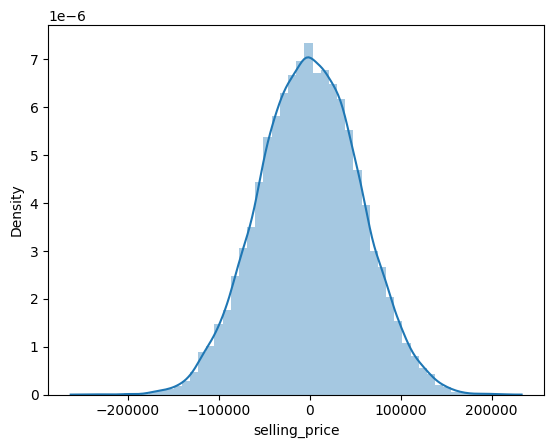

In [ ]:
# Residual analysis
sns.distplot(errors)

This plot visualizes the distribution of the residuals. Ideally, the residuals should follow a normal distribution, indicating that the model errors are random and not biased.

Text(0, 0.5, 'errors')

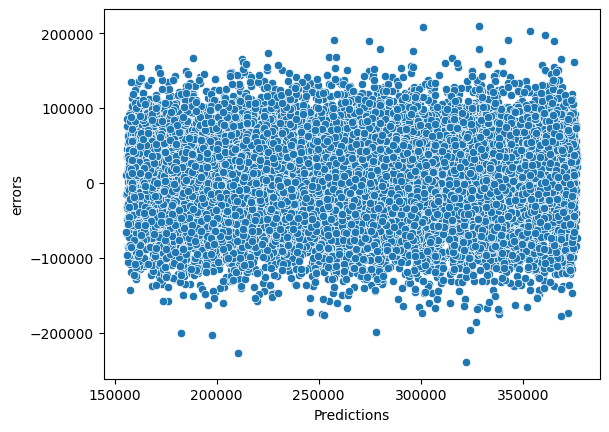

In [ ]:
# Predictions vs Residuals Plot

sns.scatterplot(x=preds, y=errors)
plt.xlabel("Predictions")
plt.ylabel("errors")

This scatter plot shows the relationship between the predicted values and the residuals. Ideally, the residuals should be randomly scattered around zero, indicating no systematic error in the model.

### Conclusion

* The code performs multiple linear regression on a dataset after standardizing the features. It evaluates the model performance using both R-squared and Adjusted R-squared, followed by calculating common error metrics like MAE, MSE, RMSE, and MAPE.
* Residual analysis is conducted to assess the quality of the model’s predictions, helping identify potential issues like non-linearity or heteroscedasticity.

## Log Transformation

<ul>
  <li>Log transformation is a mathematical operation applied to data to modify its scale, particularly useful when dealing with skewed distributions or heteroskedasticity.</li>
  <li>In a log transformation, each data point is replaced with the natural logarithm of that value. This compresses large values and expands small values, helping to spread out extreme values and make the distribution more symmetrical.</li>
  <li>Addressing Autocorrelation and Heteroskedasticity:</li>
<ul>
  <li>Autocorrelation refers to the correlation between successive observations in a time series or sequential data, which can lead to patterns in model residuals</li>
  <li>Heteroskedasticity refers to the unequal variance of errors across different values of predictor variables, violating the assumption of homoscedasticity in linear regression.</li>
  <li>Log transformation alone may not directly address autocorrelation or heteroskedasticity but can help mitigate these issues by stabilizing variance and linearizing relationships between variables, making them more amenable to modeling techniques.</li>
</ul>
</ul>

* When to Use Log Transformation:
   * Non-linearity: When the relationship between the dependent and independent variables is not linear. The log transformation can linearize the relationship.

   * Heteroscedasticity: When the variance of the residuals is not constant (heteroscedasticity), log transformation can stabilize the variance.

   * Skewed Distribution: When the dependent or independent variables are highly skewed, applying a log transformation can normalize the distribution.

   * Multiplicative Relationships: If there is a multiplicative relationship between the independent variables and the dependent variable, a log transformation will convert it into an additive model suitable for linear regression.

In [ ]:
# Performing a log transformation on the target variable (y_train and y_test) by taking the natural logarithm of each value.
Y_train = np.log(y_train)
Y_test = np.log(y_test)

<ipython-input-84-41c662f48c87>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_train)


<Axes: xlabel='selling_price', ylabel='Density'>

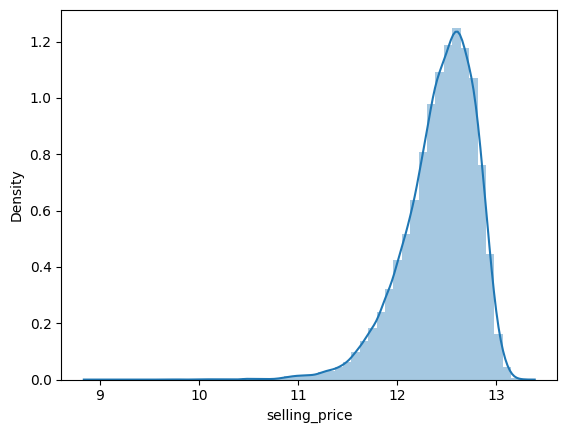

In [ ]:
sns.distplot(Y_train)

In [ ]:
final2 = LinearRegression()

In [ ]:
final2.fit(x_train, Y_train)

LinearRegression()

In [ ]:
final2.score(x_train, Y_train)

0.5227076678839913

The decrease in R<sup>2</sup> after applying the log transformation indicates that the log-transformed model is not as effective as the original model in explaining the variance in the target variable.

This suggests that the relationship between the predictors and the target variable may not be well captured by a linear model in the log-transformed space, possibly due to the transformation altering the underlying relationship between the variables.

While the original model might have appeared "perfect" due to its higher R<sup>2</sup> , it's essential to consider other factors such as the interpretability of the model and the assumptions underlying the log transformation.
